# Demand Forecasting - Feature Layer EDA

This notebook performs targeted exploratory data analysis on the feature layer to validate feature quality and understand demand behavior.

Focus areas:

* Target distribution and patterns
* Time-based seasonality
* Feature relevance (lags, rolling stats)
* Price and discount impact
* ABC-XYZ segmentation insights

This EDA is designed to support model building


## 1. Import Libraries

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
from src.utils.db import run_query
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose


## 2. Load Data

In [2]:
feature = run_query('''
    SELECT * FROM feature_layer.ml_features
''')

display(feature)

c:\Users\user\Desktop\Data Science\Machine Learning\Inventory ML System\notebooks\..\src\utils\db.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,sale_date,product_id,total_quantity,product_avg_qty,avg_selling_price,total_discount,avg_landing_cost,avg_margin_pct,has_discount,discount_rate,...,price_change_pct,l0_category_id,l1_category_id,l2_category_id,brand_name,product_age_days,abc_class,xyz_class,abc_xyz_class,demand_cov
0,2022-04-01,1,264,0.0,59.965957,46.0,55.482678,0.074774,1,0.002906,...,NaN,16,1573,1297,nutrela,0,A,X,AX,0.270206
1,2022-04-02,1,241,264.0,59.884956,0.0,52.466809,0.123733,0,0.000000,...,-0.001351,16,1573,1297,nutrela,1,A,X,AX,0.270206
2,2022-04-03,1,293,252.5,59.936330,112.0,53.991995,0.098592,1,0.006380,...,0.000858,16,1573,1297,nutrela,2,A,X,AX,0.270206
3,2022-04-04,1,162,266.0,59.940789,24.0,52.438330,0.125095,1,0.002471,...,0.000074,16,1573,1297,nutrela,3,A,X,AX,0.270206
4,2022-04-05,1,144,240.0,59.938462,24.0,54.500408,0.090714,1,0.002780,...,-0.000039,16,1573,1297,nutrela,4,A,X,AX,0.270206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702941,2022-07-09,488733,1,0.0,784.000000,0.0,752.390800,0.040300,0,0.000000,...,NaN,163,1117,697,unknown,0,C,X,CX,0.000000
702942,2022-07-10,488735,1,0.0,724.000000,0.0,694.795000,0.040300,0,0.000000,...,NaN,163,1117,697,unknown,0,C,X,CX,0.000000
702943,2022-07-09,488737,1,0.0,489.000000,0.0,503.281000,-0.029200,0,0.000000,...,NaN,163,981,981,phy,0,C,X,CX,0.000000
702944,2022-07-09,488739,1,0.0,735.000000,0.0,756.002000,-0.028600,0,0.000000,...,NaN,163,1115,358,unknown,0,C,X,CX,0.000000


## 3.Basic Overview.

In [3]:
feature.shape

(702946, 42)

In [4]:
feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702946 entries, 0 to 702945
Data columns (total 42 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   sale_date           702946 non-null  object 
 1   product_id          702946 non-null  int64  
 2   total_quantity      702946 non-null  int64  
 3   product_avg_qty     702946 non-null  float64
 4   avg_selling_price   702946 non-null  float64
 5   total_discount      702946 non-null  float64
 6   avg_landing_cost    702946 non-null  float64
 7   avg_margin_pct      702884 non-null  float64
 8   has_discount        702946 non-null  int64  
 9   discount_rate       702884 non-null  float64
 10  num_orders          702946 non-null  int64  
 11  num_cities          702946 non-null  int64  
 12  day_of_week         702946 non-null  int64  
 13  month               702946 non-null  int64  
 14  year                702946 non-null  int64  
 15  day_of_year         702946 non-nul

In [5]:
feature.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sale_date,702946,81,2022-07-10,10092,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,702946.0,NaN,NaN,NaN,317735.806241,179108.145971,1.0,112761.0,403048.0,466077.0,488746.0
total_quantity,702946.0,NaN,NaN,NaN,84.608227,421.098541,1.0,3.0,12.0,47.0,20440.0
product_avg_qty,702946.0,NaN,NaN,NaN,80.893416,384.815076,0.0,3.983871,12.571429,46.727273,15530.1375
avg_selling_price,702946.0,NaN,NaN,NaN,172.230886,196.333399,0.0,59.0,113.652618,210.0,9900.0
total_discount,702946.0,NaN,NaN,NaN,41.319283,703.29601,0.0,0.0,0.0,14.0,114898.0
avg_landing_cost,702946.0,NaN,NaN,NaN,160.686862,192.344733,0.0,53.858944,101.493638,192.505,9749.0
avg_margin_pct,702884.0,NaN,NaN,NaN,0.040777,0.795842,-348.9971,-0.048864,0.0977,0.214516,1.0
has_discount,702946.0,NaN,NaN,NaN,0.339091,0.473401,0.0,0.0,0.0,1.0,1.0
discount_rate,702884.0,NaN,NaN,NaN,0.004615,0.021114,0.0,0.0,0.0,0.003052,1.181818


| Column Name        | Description               | Type     | Category    | Notes                     |
| ------------------ | ------------------------- | -------- | ----------- | ------------------------- |
| sale_date          | Date of transaction       | datetime | Time        | Convert from object       |
| product_id         | Unique product identifier | int      | Categorical | High cardinality          |
| total_quantity     | Units sold                | int      | Target      | Prediction target         |
| avg_selling_price  | Average selling price     | float    | Numerical   | Key demand driver         |
| total_discount     | Total discount applied    | float    | Numerical   | Depends on business logic |
| avg_landing_cost   | Cost price                | float    | Numerical   | Used for margin           |
| avg_margin_pct     | Profit margin %           | float    | Numerical   | Potential leakage      |
| has_discount       | Discount flag (0/1)       | int      | Binary      | Useful feature            |
| discount_rate      | Discount percentage       | float    | Numerical   | Important for elasticity  |
| num_orders         | Number of orders          | int      | Numerical   | Possible leakage       |
| num_cities         | Number of cities          | int      | Numerical   | Post-demand signal     |
| day_of_week        | Day of week               | int      | Categorical | Weekly seasonality        |
| month              | Month                     | int      | Categorical | Seasonal pattern          |
| year               | Year                      | int      | Categorical | Trend component           |
| day_of_year        | Day index in year         | int      | Numerical   | Cyclical                  |
| week_of_year       | Week number               | int      | Categorical | Trend signal              |
| is_weekend         | Weekend flag              | int      | Binary      | Behavioral signal         |
| qty_lag1           | Previous day demand       | int      | Numerical   | Highly important          |
| qty_lag7           | Demand last week          | int      | Numerical   | Seasonality               |
| qty_lag14          | Demand 2 weeks ago        | int      | Numerical   | Redundant                 |
| qty_lag28          | Demand 4 weeks ago        | int      | Numerical   | Long-term pattern         |
| price_lag1         | Previous price            | float    | Numerical   | Short-term effect         |
| price_lag7         | Price last week           | float    | Numerical   | Trend                     |
| discount_lag1      | Previous discount flag    | int      | Binary      | Useful                    |
| discount_rate_lag1 | Previous discount rate    | float    | Numerical   | Elasticity                |
| rolling_mean_7     | 7-day avg demand          | float    | Numerical   | Trend smoothing           |
| rolling_mean_14    | 14-day avg demand         | float    | Numerical   | Medium trend              |
| rolling_mean_30    | 30-day avg demand         | float    | Numerical   | Long-term trend           |
| rolling_std_7      | 7-day variability         | float    | Numerical   | Volatility                |
| rolling_std_30     | 30-day variability        | float    | Numerical   | Stability                 |
| rolling_max_30     | Max demand (30 days)      | int      | Numerical   | Peak indicator            |
| price_change_pct   | Price change %            | float    | Numerical   | Has missing values        |
| l0_category_id     | Top category              | int      | Categorical | Hierarchical              |
| l1_category_id     | Mid category              | int      | Categorical |                           |
| l2_category_id     | Fine category             | int      | Categorical |                           |
| brand_name         | Brand                     | object   | Categorical | High cardinality          |
| product_age_days   | Product age               | int      | Numerical   | Lifecycle feature         |
| abc_class          | Sales importance class    | object   | Categorical | A/B/C segmentation        |
| xyz_class          | Demand variability class  | object   | Categorical | X/Y/Z segmentation        |
| abc_xyz_class      | Combined class            | object   | Categorical | Business feature          |
| demand_cov         | Demand variability metric | float    | Numerical   | Derived from target    |


### Dataset Overview :
- Total records: 380,768
- Total features: 41
- Time coverage: ~53 days (Apr–Jul 2022)

### Data Quality :
- No Missing Values
- Data Type Mismatch for sale_date (object to datetime)
- Most Frequent unknown brand_name.

#### Target Variable : total_quantity

count    702946.000000
mean         84.608227
std         421.098541
min           1.000000
25%           3.000000
50%          12.000000
75%          47.000000
max       20440.000000
Name: total_quantity, dtype: float64


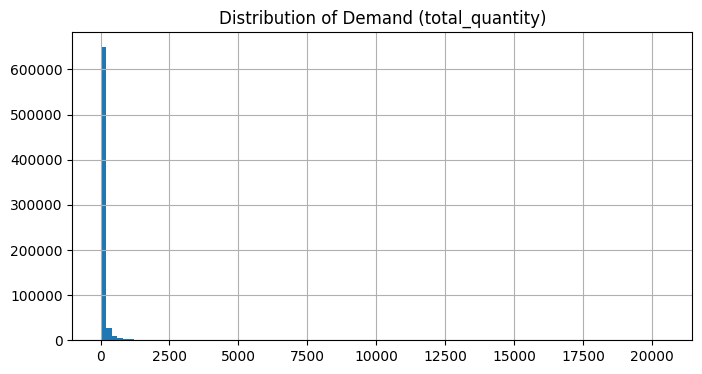

In [6]:
print(feature['total_quantity'].describe())

plt.figure(figsize=(8,4))
feature['total_quantity'].hist(bins=100)
plt.title("Distribution of Demand (total_quantity)")
plt.show()

- The total_quantity is extremely right skewed.
- mean is 101 and median is 17.
- the maximum value is 20440.
- No need of change.

### Time Based Patterns

#### Daily Trend

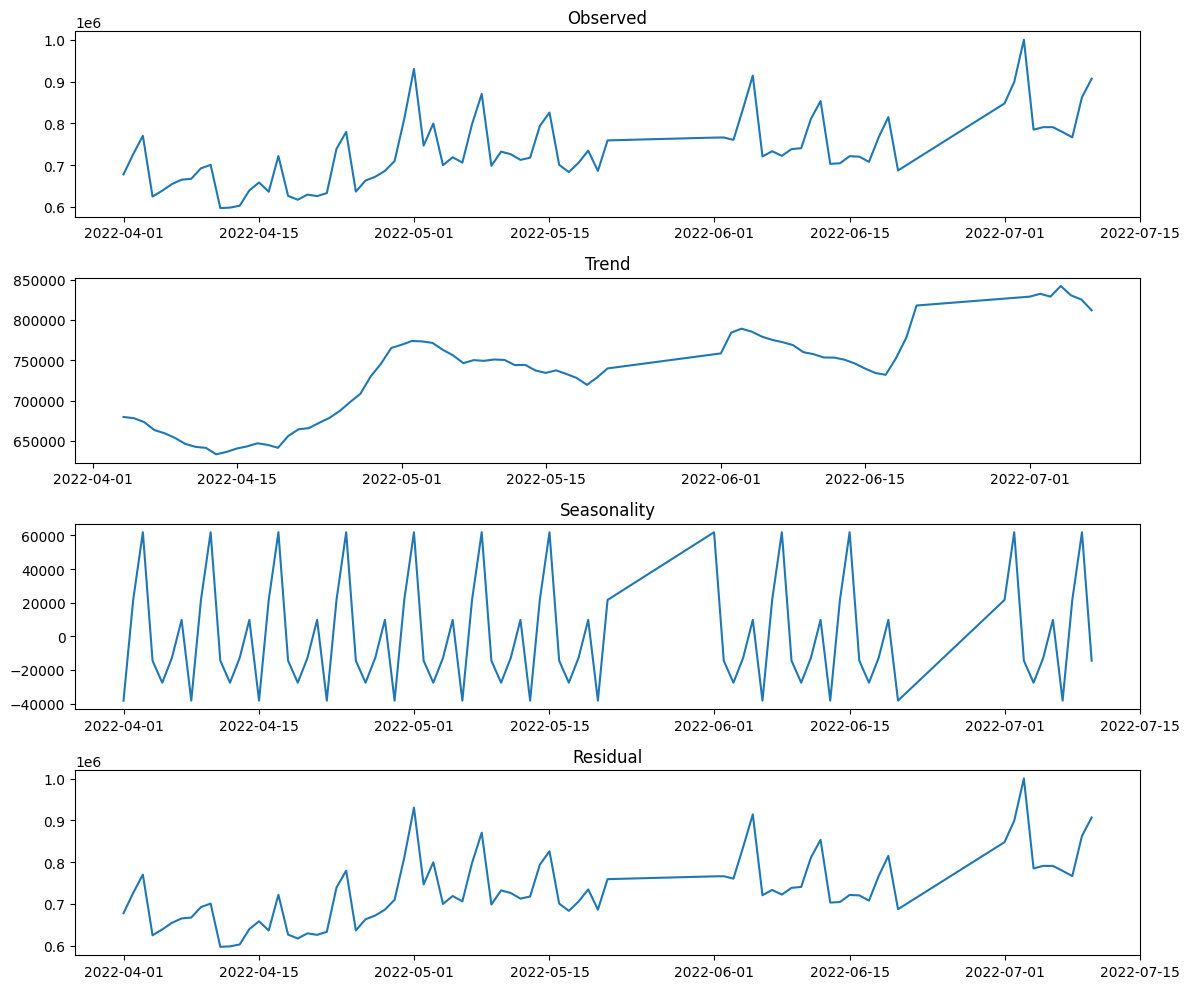

In [7]:
seasonal = feature.groupby('sale_date')['total_quantity'].sum()
result = seasonal_decompose(
    seasonal,
    model = 'additive',
    period = 7
)
plt.figure(figsize=(12,10))

plt.subplot(4,1,1)
plt.plot(seasonal.index, seasonal)
plt.title("Observed")

plt.subplot(4,1,2)
plt.plot(seasonal.index, result.trend)
plt.title("Trend")

plt.subplot(4,1,3)
plt.plot(seasonal.index, result.seasonal)
plt.title("Seasonality")

plt.subplot(4,1,4)
plt.plot(seasonal.index, result.observed)
plt.title("Residual")

plt.tight_layout()
plt.show()

#### Weekly Trend

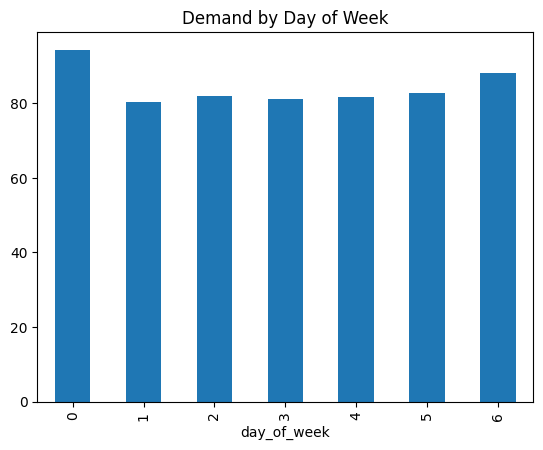

In [8]:
feature.groupby('day_of_week')['total_quantity'].mean().plot(kind='bar')
plt.title("Demand by Day of Week")
plt.show()

#### Monthly Pattern

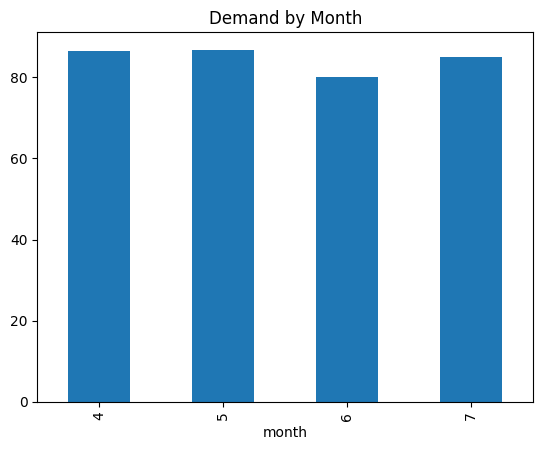

In [9]:
feature.groupby('month')['total_quantity'].mean().plot(kind='bar')
plt.title("Demand by Month")
plt.show()

#### Lag Features Correlation With Quantity.

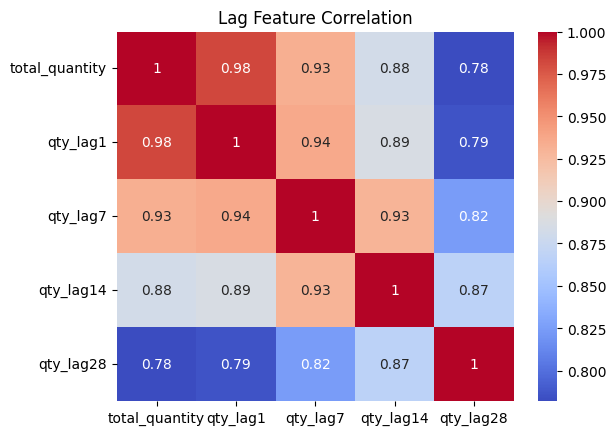

In [10]:
import seaborn as sns
lag_cols = ['qty_lag1','qty_lag7','qty_lag14','qty_lag28']
sns.heatmap(feature[['total_quantity'] + lag_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Lag Feature Correlation")
plt.show()

#### rolling mean features corelation with total quantity.

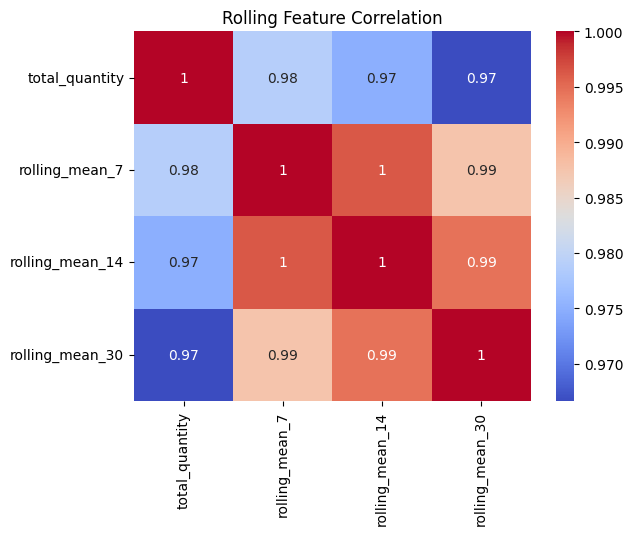

In [11]:
rolling_cols = ['rolling_mean_7','rolling_mean_14','rolling_mean_30']

sns.heatmap(feature[['total_quantity'] + rolling_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Rolling Feature Correlation")
plt.show()

#### Price and Discount Analysis

In [12]:
feature[['avg_selling_price','total_quantity']].corr()

,avg_selling_price,total_quantity
avg_selling_price,1.000000,-0.095885
total_quantity,-0.095885,1.000000


In [13]:
feature[['price_change_pct','total_quantity']].corr()

,price_change_pct,total_quantity
price_change_pct,1.000000,-0.001612
total_quantity,-0.001612,1.000000


In [14]:
feature.groupby('has_discount')['total_quantity'].mean()

has_discount
0     16.391844
1    217.565826
Name: total_quantity, dtype: float64

In [15]:
feature[['discount_rate','total_quantity']].corr()

,discount_rate,total_quantity
discount_rate,1.000000,0.010748
total_quantity,0.010748,1.000000


#### Product Segmentation


In [16]:
feature.groupby('abc_xyz_class')['total_quantity'].mean().sort_values()

abc_xyz_class
CY      7.277116
CX     10.168225
CZ     12.509763
BY     35.464511
BZ     40.522700
BX     42.626246
AZ    198.844072
AY    208.552305
AX    335.207694
Name: total_quantity, dtype: float64

In [17]:
feature.groupby('abc_class')['total_quantity'].mean()

abc_class
A    310.341132
B     39.541007
C      8.198140
Name: total_quantity, dtype: float64

#### Variability Analysis

In [18]:
feature[['demand_cov','total_quantity']].corr()

,demand_cov,total_quantity
demand_cov,1.000000,-0.152785
total_quantity,-0.152785,1.000000


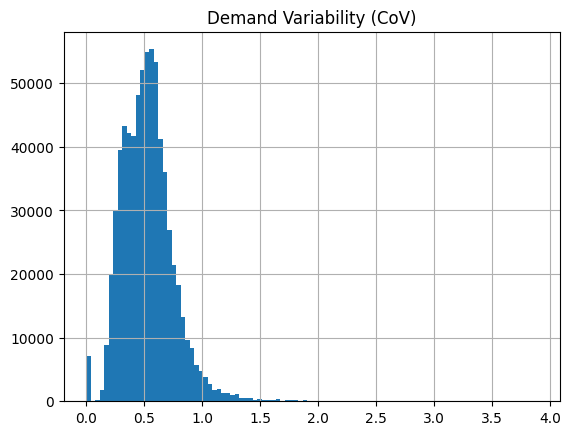

In [19]:
feature['demand_cov'].hist(bins=100)
plt.title("Demand Variability (CoV)")
plt.show()

#### Overview

The time series has been decomposed into four components:

Observed (Original Demand)
Trend (Long-term movement)
Seasonality (Repeating patterns)
Residual (Unexplained variation)

#### Observed Data

The actual demand values over time.

Insights:
- Demand exhibits high volatility with frequent spikes and drops.
- Several sharp peaks (near 1M) indicate:
- High-demand events
- Promotions or bulk purchases
- There is a gradual increase in demand toward later dates
#### Trend Component

Underlying long-term direction of demand.

Insights:
- Initial decline in early April
- Strong upward trend from mid-April to early May
- Slight dip in mid-May to mid-June
- Clear growth trend from mid-June to July

Interpretation:

Demand is overall increasing over time
Suggests:
Product gaining popularity
Seasonal uplift
Business growth or improved availability
#### Seasonality Component

Repeating patterns at fixed intervals.

Insights:
Clear and consistent cyclical pattern
Peaks and dips occur at regular intervals (~7 days)

Strong evidence of:

Weekly seasonality

interpretation:

Higher sales on specific days (e.g., weekends)
Lower demand on others (e.g., weekdays)

Seasonality is strong and stable
Important feature for modeling

#### Residual Component

Random noise after removing trend and seasonality.

Insights:
Residuals show high variance
Presence of large spikes indicates:
Sudden demand shocks
External factors (promotions, stockouts, holidays)

Demand influenced by external variables

### Key Observations

1. Strong Weekly Seasonality
Consistent repeating pattern
Must include:
day_of_week feature

2. Upward Demand Trend
Overall growth in demand
Indicates:
Increasing product adoption

3. High Demand Volatility
Large fluctuations even after removing trend
Indicates:
Unstable demand patterns
Need for robust models

### Decisions.
1. Classical models alone are not sufficient
2. Feature-driven models are preferred

Use:

Lag features (t-1, t-7)
Rolling mean / std
Day-of-week encoding
3. Probabilistic forecasting is Preferred
Because:
Demand is highly variable
Residuals are large

Use:

Quantile regression (P10, P50, P90)
To estimate uncertainty - safety stock


### Feature Selection for Modeling

Before building the forecasting models, careful feature selection was performed to ensure:

- No data leakage
- Only features available at prediction time
- Removal of redundant or low-value features
- Better generalization and model stability

#### Features Removed

The following features were excluded due to leakage risk or limited usefulness:

- Target leakage features:
- - avg_margin_pct, num_orders, num_cities, demand_cov
- - These are derived from or influenced by actual demand.
- Future or unstable features:
- - qty_lag14, qty_lag28
- - Not reliable given only 4 months of data.
- Redundant / highly correlated features:
- - Higher-order lags and long rolling windows
- - Add noise without new information.
- Granular time features:
- - day_of_year
- - Not meaningful for short time span

#### Selected Features

The final feature set focuses on temporal patterns, short-term trends, and product-level information:

- Time-based features:
day_of_week, month, week_of_year, is_weekend
- Lag features (autoregressive signal):
qty_lag1, qty_lag7
- Rolling statistics (short-term trend & volatility):
rolling_mean_7, rolling_std_7
- Price & discount signals:
avg_selling_price, discount_rate, has_discount, price_change_pct
- Product metadata:
product_id, l1_category_id, l2_category_id, product_age_days

# Model Building And Comparing.

In [20]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb


# Evaluation

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100

    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%")
    return mae, rmse, mape


# Data Loading

df = run_query("SELECT * FROM feature_layer.ml_features;")
df["sale_date"] = pd.to_datetime(df["sale_date"])

df = df.sort_values(["product_id", "sale_date"])

# Features

FEATURES = [
    "day_of_week", "month", "is_weekend", "week_of_year",
    "qty_lag1", "qty_lag7",
    "rolling_mean_7", "rolling_std_7",
    "avg_selling_price", "discount_rate", "has_discount", "price_change_pct","product_avg_qty",
    "product_id", "l1_category_id", "l2_category_id", "product_age_days"
]

TARGET = "total_quantity"

X = df[FEATURES].fillna(0)
y = df[TARGET]


# Train - Test Split with Time

split_date = df["sale_date"].max() - pd.Timedelta(days=30)

train_idx = df["sale_date"] <= split_date
test_idx = df["sale_date"] > split_date

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# LOG TRANSFORM
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

df_test = df[test_idx]


# Naive - Baseline Model

naive_pred = df_test["qty_lag7"].fillna(0)
evaluate(y_test, naive_pred, "Naive (lag7)")


# Feature Group

num_features = [
    "qty_lag1", "qty_lag7",
    "rolling_mean_7", "rolling_std_7",
    "avg_selling_price", "discount_rate", "price_change_pct","product_avg_qty",
    "product_age_days"
]

cat_features = [
    "day_of_week", "month", "is_weekend",
    "product_id", "l1_category_id", "l2_category_id"
]


# Preprocessor

# For Ridge (needs scaling + encoding)
ridge_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

# For Tree Models (NO scaling, NO one-hot)
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("all", "passthrough", num_features + cat_features)
    ]
)


# Models

models = {
    "Ridge": Pipeline([
        ("preprocessor", ridge_preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),

    "RandomForest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            n_jobs=-1,
            random_state=42
        ))
    ]),

    "LightGBM": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", lgb.LGBMRegressor(
            random_state=42
        ))
    ])
}


# Train and Evaluate

results = []

for name, pipe in models.items():

    # Train in log space
    pipe.fit(X_train, y_train_log)

    # Predict in log space
    preds_log = pipe.predict(X_test)

    # Convert back to original scale
    preds = np.expm1(preds_log)

    # Evaluate in original scale
    mae, rmse, mape = evaluate(y_test, preds, name)

    results.append({
        "model": name,
        "mae": mae,
        "rmse": rmse,
        "mape": mape
    })


# Results

results_df = pd.DataFrame(results)

print("\nModel Comparison:\n", results_df)

c:\Users\user\Desktop\Data Science\Machine Learning\Inventory ML System\notebooks\..\src\utils\db.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


Naive (lag7): MAE=23.21, RMSE=99.09, MAPE=76.51%
Ridge: MAE=245.67, RMSE=24846.15, MAPE=94.47%
RandomForest: MAE=13.53, RMSE=66.17, MAPE=45.64%
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2811
[LightGBM] [Info] Number of data points in the train set: 510330, number of used features: 15
[LightGBM] [Info] Start training from score 2.816806


c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM: MAE=14.83, RMSE=115.69, MAPE=42.96%

Model Comparison:
           model         mae          rmse       mape
0         Ridge  245.673781  24846.150217  94.465444
1  RandomForest   13.525085     66.174881  45.636287
2      LightGBM   14.827200    115.693499  42.963004


##### Model Optimization

After establishing a stable baseline and evaluating model performance, LightGBM is selected for further improvement due to its strong performance in capturing demand patterns.

Hyperparameter tuning will be performed on Hyper Parameter Tuning.


##### Hyper Parameter Tuning.

In [24]:
from sklearn.model_selection import RandomizedSearchCV

# LightGBM Pipeline (same as yours)
lgb_pipe = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", lgb.LGBMRegressor(random_state=42))
])

# Parameter space
param_dist = {
    "model__n_estimators": [300, 500, 800],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__num_leaves": [31, 64, 128],
    "model__max_depth": [-1, 5, 10],
    "model__min_child_samples": [5, 10, 20],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=lgb_pipe,
    param_distributions=param_dist,
    n_iter=15,   # keep small for speed
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Train on log-transformed target
random_search.fit(X_train, y_train_log)

# Best model
best_lgb = random_search.best_estimator_

print("\nBest Parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2811
[LightGBM] [Info] Number of data points in the train set: 510330, number of used features: 15
[LightGBM] [Info] Start training from score 2.816806

Best Parameters:
{'model__subsample': 0.8, 'model__num_leaves': 128, 'model__n_estimators': 300, 'model__min_child_samples': 20, 'model__max_depth': 10, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.7}


In [25]:
# Predict (log space)
preds_log = best_lgb.predict(X_test)

# Convert back
preds = np.expm1(preds_log)

# Evaluate
evaluate(y_test, preds, "Tuned LightGBM")

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Tuned LightGBM: MAE=14.37, RMSE=102.99, MAPE=42.29%


(14.365739109121346,
 np.float64(102.98788947605851),
 np.float64(42.293916413187134))